# Scottish Premiership Season Simulation
## A Poisson Goal Model and Monte Carlo Analysis

**Author:** Jake Oliver

**Date:** May 2026

**Data Source:** football-data.co.uk

## Introduction

This project models and simulates Scottish Premiership football seasons using statistical methods drawn from probability theory.

The central question is: **given historical match results, can we estimate each team's underlying attacking and defensive strength, and use this to simulate realistic season outcomes?**

Goals scored in football are widely modelled as Poisson-distributed events. This is a reasonable assumption because goals are rare, discrete, independent events occuring over a fixed time period - conditions that satisfy a Poisson process. Each team's expected goals in a given match is estimated from their historical attack strength, their opponent's defensive weakness, and a home advantage factor.

Once we have a model for individual match scorelines, we run a **Monte Carlo simulation** - repeating a full 38-game season thousands of times - to estimate probabilities of outcomes such as title wins, European qualification, and relegation.

This approach is grounded in the following areas of study:

-Poisson random variables and modelling

-Parameter estimation from real data

-Monte Carlo simulation methods

-Exploratory data analysis and visualisation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson

## Libraries

-**pandas** - data loading and manipulation

-**numpy** - numerical operations

-**matplotlib/seaborn** - visualisation

-**scipy.stats** - Poisson distribution functions for our goal model

## Data

Match results are sourced from football-data.co.uk, a free repository of historical football results accross European leagues. The dataset  used is the 2023/2024 Scottish Premiership season.

Each row represents a single match and includes the home team, away team, and full time score among other statiistics. We will primarily use the following columns:

-"HomeTeam" / "AwayTeam" - the two clubs

-"FTHG" / "FTAG" - Full Time Home Goals / Full Time Away Goals

-"FTR" - Full Time Result (H/D/A)

In [6]:
df = pd.read_csv('SC0.csv')
print(df.shape)
df.head()

(228, 106)


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,SC0,05/08/2023,12:30,Celtic,Ross County,4,2,H,3,0,...,4.18,-3.00,1.93,1.93,1.96,1.91,2.19,1.95,1.97,1.84
1,SC0,05/08/2023,15:00,Dundee,Motherwell,1,1,D,0,1,...,1.66,-0.25,1.98,1.88,2.04,1.88,2.07,1.93,1.97,1.85
2,SC0,05/08/2023,15:00,Livingston,Aberdeen,0,0,D,0,0,...,1.69,0.00,1.95,1.90,2.03,1.88,2.04,1.95,1.97,1.85
3,SC0,05/08/2023,15:00,St Johnstone,Hearts,0,2,A,0,0,...,1.73,0.25,2.03,1.83,2.03,1.88,2.11,1.88,2.01,1.80
4,SC0,05/08/2023,17:15,Kilmarnock,Rangers,1,0,H,0,0,...,2.21,1.25,2.03,1.83,2.04,1.87,2.09,1.90,1.97,1.84


## Data Preparation

The raw dataset contains 106 columns, the majority of which are betting odds from various bookmakers. We only need the match result columns for our model, so we select a clean subset of the data.

In [8]:
df = df[['Date','HomeTeam','AwayTeam','FTHG','FTAG','FTR']].copy()
df.columns = ['Date','HomeTeam','AwayTeam','HomeGoals','AwayGoals','Result']
df['Date'] = pd.to_datetime(df['Date'], dayfirst = True)

print(df.shape)
print(df.isnull().sum())
df.head()

(228, 6)
Date         0
HomeTeam     0
AwayTeam     0
HomeGoals    0
AwayGoals    0
Result       0
dtype: int64


,Date,HomeTeam,AwayTeam,HomeGoals,AwayGoals,Result
0,2023-08-05,Celtic,Ross County,4,2,H
1,2023-08-05,Dundee,Motherwell,1,1,D
2,2023-08-05,Livingston,Aberdeen,0,0,D
3,2023-08-05,St Johnstone,Hearts,0,2,A
4,2023-08-05,Kilmarnock,Rangers,1,0,H


## Exploratory Data Analysis

Before building a model, we explore the data to understand the distribution of goals scored. A key assumption of our model is that goals follow a Poisson distribution. We check this visually by comparing the observed goal distribution against what a Poisson distribution would predict.

In [10]:
home_goals = df['HomeGoals']
away_goals = df['AwayGoals']
all_goals = pd.concat([home_goals,away_goals])

print(f"Average home goals per game: {home_goals.mean():.3f}")
print(f"Average away goals per game: {away_goals.mean():.3f}")
print(f"Average total goals per team per game: {all_goals.mean():.3f}")
print(f"Average total goals per match: {(home_goals + away_goals).mean():.3f}")

print(f"\nHome wins: {(df['Result']=='H').sum()}")
print(f"Draws: {(df['Result']=='D').sum()}")
print(f"Away wins: {(df['Result']=='A').sum()}")

Average home goals per game: 1.518
Average away goals per game: 1.241
Average total goals per team per game: 1.379
Average total goals per match: 2.759

Home wins: 98
Draws: 61
Away wins: 69


## Observations

-Home teams average **1.518 goals per game** compared to **1.241 for away teams**, confirming a home advantage effect that our model will need to account for.

-Home wins account for 43% of matches, away wins 30%, and draws 27% - a fairly reasonable distribution for Scottish football.

-The average goals per team per game is **1.379**, with an average of **2.759 total goals per match**.

These averages will serve as the foundation for estimating each teams attack and defence strength relative to the league average.

### Goal Distribution vs Poisson

We visually inspect whether the observed goal distibutions follow a Poisson distribution - a core assumption of our model. If the observed frequencies align closely with the theoretical Poisson probabilities, this justifies our modelling approach.

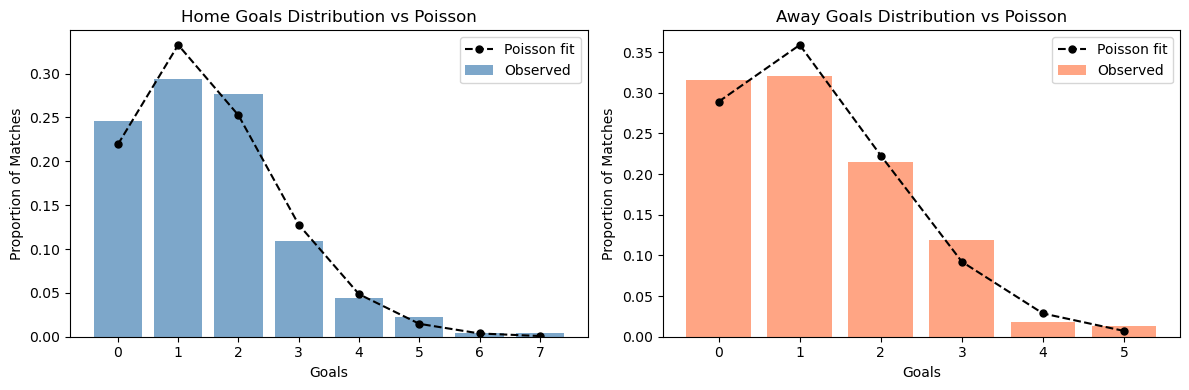

In [13]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

for ax, goals, label, color in zip(axes,
                                   [home_goals,away_goals],
                                   ['Home Goals','Away Goals'],
                                   ['steelblue','coral']):
    observed = goals.value_counts(normalize=True).sort_index()
    poisson_expected = [poisson.pmf(k, goals.mean()) for k in observed.index]
    ax.bar(observed.index, observed.values, alpha=0.7, color=color, label='Observed')
    ax.plot(observed.index, poisson_expected, 'ko--', markersize=5, label='Poisson fit')
    ax.set_title(f'{label} Distribution vs Poisson')
    ax.set_xlabel('Goals')
    ax.set_ylabel('Proportion of Matches')
    ax.legend()

plt.tight_layout()
plt.show()

### Interpretation

The Poisson distribution provides a reasonable but imperfect fit to the observed goal data. For home goals, the fit is fairly close, with the model capturing the general shape of the distribution well. For away goals, the fit is weaker - the observed frequency of 0 and 1 goal outcomes is noticeably flatter than the Poisson Curve predicts, suggesting the single rate parameter does not fully capture away scoring patterns.

This is a known limitation of the basic Poisson model in football analytics. For the purposes of this project we proceed with the Poisson assumption as a well-established baseline, keeping this limitation in mind when interpreting our simulation results.

## The Poisson Goal Model

To simulate matches we need to estimate the expected goals for each team in any given fixture. We model this using three components:

-**Attack Strength** - how prolific a team is relative to the league average

-**Defence Weakness** - how many goals a team concedes relative to the league average

-**Home Advantage** - a multiplicative factor applied to the home team's expected goals

For a given match, expected goals are calculated as:

-Home xG = attack_strength(Home)*defence_weakness(Away)*average_home_goals

-Away xG = attack_strength(Away)*defence_weakness(Home)*average_away_goals

These expected goals values then serve as the rate parameter (lambda) of a Poisson distribution from which we draw simulated scorelines.


In [16]:
avg_home_goals = df['HomeGoals'].mean()
avg_away_goals = df['AwayGoals'].mean()

teams = sorted(df['HomeTeam'].unique())
print(f"Teams in dataset: {len(teams)}")
print(teams)            

Teams in dataset: 12
['Aberdeen', 'Celtic', 'Dundee', 'Hearts', 'Hibernian', 'Kilmarnock', 'Livingston', 'Motherwell', 'Rangers', 'Ross County', 'St Johnstone', 'St Mirren']


### Estimating Attack and Defence Strength

For each team we calculate:

-**Attack Strength** - the team's average goals scored divided by the league average goals scored, calculated separately for home and away matches.

-**Defence Weakness** - the team's average goals conceded divided by the league average goals conceded, again split by home and away.

A value above 1.0 for Attack Strength means the team is stronger than average and less than 1.0 means weaker than average.

A value below 1.0 for Defence Weakness means they are better than average and greater than 1.0 means they are worse than average.

In [18]:
strength_table = []

for team in teams:
    home_matches = df[df['HomeTeam'] == team]
    away_matches = df[df['AwayTeam'] == team]
    home_attack = home_matches['HomeGoals'].mean() / avg_home_goals
    home_defence = home_matches['AwayGoals'].mean() / avg_away_goals
    away_attack = away_matches['AwayGoals'].mean() / avg_away_goals
    away_defence = away_matches['HomeGoals'].mean() / avg_home_goals
    strength_table.append({
    'Team':team,
    'Home Attack': round(home_attack,3),
    'Home Defence': round(home_defence,3),
    'Away Attack': round(away_attack,3),
    'Away Defence': round(away_defence,3)
    })

strength_df = pd.DataFrame(strength_table).set_index('Team')
strength_df

,Home Attack,Home Defence,Away Attack,Away Defence
Team,,,,
Aberdeen,0.902,0.975,0.933,1.006
Celtic,1.734,0.636,1.908,0.520
Dundee,0.832,1.187,1.060,1.387
Hearts,1.110,0.806,0.933,0.798
Hibernian,0.867,1.102,1.145,1.145
Kilmarnock,0.971,0.890,0.763,0.798
Livingston,0.486,1.060,0.636,1.561
Motherwell,1.110,1.314,1.018,0.971
Rangers,1.769,0.763,1.527,0.486


### Strength Table Observations

The results align well with the 2023/2024 Scottish Premiership season. Celtic and Rangers show the highest attack strength values both home and away, consistent with their dominance of the division. At the other end, Livingston and St Johnstone show notably weak attacking numbers, reflecting their relegation battle.

Defence weakness values below 1.0 indicate a stronger than average defence - Celtic's away defence weakness of 0.52 is particularly striking, meaning opponents scored at roughly half the league average against them in fixtures where they played away.

These strength values will now be used to calculate expected goals for any simulated fixture.

### Simulating Individual Matches

With attack and defence strengths estimated, we can calculate the expected goals (lambda) for any fixture. We then draw a random scoreline from a Poisson distribution using these lambda values as the rate parameter.

For a given match:

Home xG (lambda) = Home Attack(Home Team) * Home Defence(Away Team) * avg_home_goals

Away xG (lambda) = Away Attack(Away Team) * Away Defence (Home Team) * avg_away_goals

Each simulated scoreline is an independent Poisson draw - meaning the home and away goals are simulated separately and do not influence eachother.

In [21]:
def simulate_match(home_team, away_team):
    home_lambda = (strength_df.loc[home_team,'Home Attack'] *
                   strength_df.loc[away_team,'Home Defence'] *
                   avg_home_goals)
    away_lambda = (strength_df.loc[away_team,'Away Attack'] *
                   strength_df.loc[home_team,'Away Defence'] *
                   avg_away_goals)
    home_goals = np.random.poisson(home_lambda)
    away_goals = np.random.poisson(away_lambda)
    return home_goals, away_goals

#Test - Celtic vs Rangers Simulated 10 times
print("Celtic vs Rangers simulated scorelines:")
for i in range(10):
    h, a = simulate_match('Celtic','Rangers')
    print(f" Celtic {h} - {a} Rangers")
    

Celtic vs Rangers simulated scorelines:
 Celtic 4 - 1 Rangers
 Celtic 0 - 0 Rangers
 Celtic 1 - 0 Rangers
 Celtic 4 - 3 Rangers
 Celtic 1 - 2 Rangers
 Celtic 4 - 3 Rangers
 Celtic 3 - 1 Rangers
 Celtic 2 - 1 Rangers
 Celtic 2 - 1 Rangers
 Celtic 1 - 1 Rangers


### Match Simulation Test

Testing the simulation function with 10 Celtic vs Rangers fixtures produces a variety of realistic scorelines. Celtic win the majority of simulated matches as expected given their home attack strength and Rangers' defensive weakness away from home.

Occasional outlier scorelines such as heavy wins reflect the nature of Poisson sampling - low probability high scoring outcomes will appear accross a large number of simulations, mirroring the unpredictability seen in real football.

## Monte Carlo Season Simulation

### SPFL Structure

The Scottish Premiership uses a split structure:

- **Regular season (33 games):** each team plays every other team 3 times. 
  For each pair, one team hosts twice and the other once, assigned randomly 
  so the overall home/away balance evens out across the season.
  
- **The split:** after 33 games the league divides into top 6 and bottom 6.

- **Post-split (5 games):** each team plays the other 5 teams in their half once,
  with home/away assigned to complete a 2-home 2-away balance.

- **Total: 38 games per team.**

We simulate this full structure 10,000 times and record the final league table each time.

In [24]:
from itertools import combinations

def generate_regular_season(teams):
    fixtures = []
    # For each pair, randomly decide who gets the extra home game
    for team1, team2 in combinations(teams, 2):
        if np.random.random() > 0.5:
            fixtures.extend([(team1, team2), (team1, team2), (team2, team1)])
        else:
            fixtures.extend([(team2, team1), (team2, team1), (team1, team2)])
    return fixtures

def simulate_regular_season(teams):
    fixtures = generate_regular_season(teams)
    
    # Initialise points table
    table = {team: {'P': 0, 'W': 0, 'D': 0, 'L': 0, 'GF': 0, 'GA': 0, 'Pts': 0} 
             for team in teams}
    
    # Track home games per pair for post-split balancing
    home_counts = {(t1, t2): 0 for t1 in teams for t2 in teams if t1 != t2}
    
    for home, away in fixtures:
        hg, ag = simulate_match(home, away)
        home_counts[(home, away)] += 1
        
        # Update table
        for team, gf, ga in [(home, hg, ag), (away, ag, hg)]:
            table[team]['P'] += 1
            table[team]['GF'] += gf
            table[team]['GA'] += ga
        
        if hg > ag:
            table[home]['W'] += 1; table[home]['Pts'] += 3
            table[away]['L'] += 1
        elif hg < ag:
            table[away]['W'] += 1; table[away]['Pts'] += 3
            table[home]['L'] += 1
        else:
            table[home]['D'] += 1; table[home]['Pts'] += 1
            table[away]['D'] += 1; table[away]['Pts'] += 1
    
    return table, home_counts

# Test
table, home_counts = simulate_regular_season(teams)
regular_df = pd.DataFrame(table).T
regular_df['GD'] = regular_df['GF'] - regular_df['GA']
regular_df = regular_df.sort_values('Pts', ascending=False)
print("Table after regular season:")
regular_df[['P', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']]

Table after regular season:


,P,W,D,L,GF,GA,GD,Pts
Rangers,33,23,5,5,80,27,53,74
Celtic,33,22,5,6,82,31,51,71
Motherwell,33,17,3,13,51,47,4,54
Hearts,33,14,10,9,56,41,15,52
Aberdeen,33,13,8,12,53,54,-1,47
Kilmarnock,33,12,9,12,40,47,-7,45
Dundee,33,12,8,13,49,57,-8,44
Hibernian,33,12,6,15,55,59,-4,42
St Mirren,33,10,7,16,31,42,-11,37
Livingston,33,8,7,18,22,50,-28,31


### The Split

After 33 games the league divides into top 6 and bottom 6. Each team then plays the other 5 teams in their half once more. Home/Away assignment in the post split fixtures is determined by the regular season - whichever team hosted fewer times against that opponent gets the home game, completing the 2-home 2-away balance across all 4 meetings.

In [26]:
def generate_split_fixtures(top6, bottom6, home_counts):
    split_fixtures = []
    
    for group in [top6, bottom6]:
        for team1, team2 in combinations(group, 2):
            t1_home = home_counts[(team1, team2)]
            if t1_home < 2:
                split_fixtures.append((team1, team2))
            else:
                split_fixtures.append((team2, team1))
    
    return split_fixtures

def simulate_full_season(teams):
    # Regular season
    table, home_counts = simulate_regular_season(teams)
    
    # Save regular season table
    regular_df = pd.DataFrame(table).T.copy()
    regular_df['GD'] = regular_df['GF'] - regular_df['GA']
    regular_df = regular_df.sort_values('Pts', ascending=False)
    
    # Determine split
    sorted_teams = sorted(table.keys(), 
                         key=lambda t: (table[t]['Pts'], table[t]['GF'] - table[t]['GA']), 
                         reverse=True)
    top6 = sorted_teams[:6]
    bottom6 = sorted_teams[6:]
    
    # Post-split fixtures
    split_fixtures = generate_split_fixtures(top6, bottom6, home_counts)
    
    # Simulate post-split
    for home, away in split_fixtures:
        hg, ag = simulate_match(home, away)
        
        for team, gf, ga in [(home, hg, ag), (away, ag, hg)]:
            table[team]['P'] += 1
            table[team]['GF'] += gf
            table[team]['GA'] += ga
        
        if hg > ag:
            table[home]['W'] += 1; table[home]['Pts'] += 3
            table[away]['L'] += 1
        elif hg < ag:
            table[away]['W'] += 1; table[away]['Pts'] += 3
            table[home]['L'] += 1
        else:
            table[home]['D'] += 1; table[home]['Pts'] += 1
            table[away]['D'] += 1; table[away]['Pts'] += 1
    
    # Post-split tables for each half
    final_table = pd.DataFrame(table).T.copy()
    final_table['GD'] = final_table['GF'] - final_table['GA']
    
    top6_df = final_table.loc[top6].sort_values('Pts', ascending=False)
    bottom6_df = final_table.loc[bottom6].sort_values('Pts', ascending=False)
    
    return regular_df, top6_df, bottom6_df

# Test single full season
regular_df, top6_df, bottom6_df = simulate_full_season(teams)

cols = ['P', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']

print("=== Regular Season (33 games) ===")
print(regular_df[cols].to_string())
print("\n=== Top 6 (after split) ===")
print(top6_df[cols].to_string())
print("\n=== Bottom 6 (after split) ===")
print(bottom6_df[cols].to_string())

=== Regular Season (33 games) ===
               P   W   D   L  GF  GA  GD  Pts
Celtic        33  24   6   3  85  21  64   78
Rangers       33  21   2  10  77  36  41   65
Hearts        33  14  12   7  54  42  12   54
Kilmarnock    33  13  11   9  48  43   5   50
Motherwell    33  14   7  12  51  58  -7   49
Hibernian     33  13   9  11  57  48   9   48
Dundee        33  11   8  14  41  58 -17   41
Aberdeen      33  11   6  16  40  57 -17   39
Ross County   33  10   7  16  39  62 -23   37
St Mirren     33   7  10  16  33  50 -17   31
St Johnstone  33   6  10  17  22  44 -22   28
Livingston    33   4  12  17  27  55 -28   24

=== Top 6 (after split) ===
             P   W   D   L   GF  GA  GD  Pts
Celtic      38  28   6   4  104  26  78   90
Rangers     38  24   3  11   88  42  46   75
Hearts      38  15  15   8   61  49  12   60
Motherwell  38  16   8  14   55  66 -11   56
Kilmarnock  38  13  13  12   50  53  -3   52
Hibernian   38  14  10  14   63  61   2   52

=== Bottom 6 (after spl

## Running 10,000 Simulations

We now run the full season simulation 10,000 times, recording the final league position of each team after the split. This gives us a distribution of outcomes from which we can estimate probabilities for events such as:

-Winning the title

-Finishing in the top 6

-Finishing bottom and being relegated

In [28]:
N_SIMULATIONS = 10000

# Track final positions across all simulations
position_counts = {team: {pos: 0 for pos in range(1, 13)} for team in teams}

for i in range(N_SIMULATIONS):
    regular_df, top6_df, bottom6_df = simulate_full_season(teams)
    
    # Combine top and bottom 6 into single final standings
    final_df = pd.concat([top6_df, bottom6_df])
    final_df = final_df.sort_values(['Pts', 'GD'], ascending=False)
    
    for pos, team in enumerate(final_df.index, start=1):
        position_counts[team][pos] += 1
    
    if (i + 1) % 1000 == 0:
        print(f"Simulations completed: {i + 1}")

print("\nDone!")

Simulations completed: 1000
Simulations completed: 2000
Simulations completed: 3000
Simulations completed: 4000
Simulations completed: 5000
Simulations completed: 6000
Simulations completed: 7000
Simulations completed: 8000
Simulations completed: 9000
Simulations completed: 10000

Done!


## Simulation results

We convert the position counts from 10,000 simulations into probabilities for key outcomes. Note that European qualification spots vary year to year depending on Scotland's UEFA coefficient ranking. For the purposes of this analysis we use the 2023/24 allocation as a rough guide:

- **Title** — finishing 1st, qualifying for the Champions League
  
- **Europe** — finishing in the top 4, covering Europa League and Conference League spots

- **Top 6** — qualifying for the post-split top half

- **Bottom 6** — finishing in the lower half of the split

- **Playoff** — finishing 11th, entering a relegation playoff against a Championship side

- **Automatic Relegation** — finishing 12th, dropping directly to the Championship

Each probability is estimated from 10,000 simulated seasons using the Poisson goal model built from 2023/24 match data. A team's probability reflects how often they achieved that outcome across all simulations, given their estimated attack and defence strengths.

In [30]:
results = []

for team in teams:
    title = position_counts[team][1] / N_SIMULATIONS * 100
    champions_league = position_counts[team][1] / N_SIMULATIONS * 100
    europe = sum(position_counts[team][pos] for pos in range(1, 5)) / N_SIMULATIONS * 100
    top6 = sum(position_counts[team][pos] for pos in range(1, 7)) / N_SIMULATIONS * 100
    bottom6 = sum(position_counts[team][pos] for pos in range(7, 13)) / N_SIMULATIONS * 100
    playoff = position_counts[team][11] / N_SIMULATIONS * 100
    automatic_relegation = position_counts[team][12] / N_SIMULATIONS * 100
    
    results.append({
        'Team': team,
        'Title %': round(title, 1),
        'Champions League %': round(champions_league, 1),
        'Europe %': round(europe, 1),
        'Top 6 %': round(top6, 1),
        'Bottom 6 %': round(bottom6, 1),
        'Playoff %': round(playoff, 1),
        'Relegation %': round(automatic_relegation, 1)
    })

results_df = pd.DataFrame(results).set_index('Team')
results_df = results_df.sort_values('Top 6 %', ascending=False)
results_df

,Title %,Champions League %,Europe %,Top 6 %,Bottom 6 %,Playoff %,Relegation %
Team,,,,,,,
Celtic,73.7,73.7,100.0,100.0,0.0,0.0,0.0
Rangers,26.3,26.3,100.0,100.0,0.0,0.0,0.0
Hearts,0.0,0.0,76.0,93.1,6.9,0.0,0.0
Kilmarnock,0.0,0.0,38.0,71.2,28.8,0.5,0.0
Motherwell,0.0,0.0,25.4,59.4,40.6,0.9,0.2
Aberdeen,0.0,0.0,21.7,56.0,44.0,1.1,0.3
St Mirren,0.0,0.0,18.4,49.9,50.1,1.4,0.4
Hibernian,0.0,0.0,16.4,48.0,52.0,1.7,0.4
Dundee,0.0,0.0,3.5,17.2,82.8,8.8,2.6


### Results Interpretation

The simulation results align closely with the actual 2023/24 Scottish Premiership season, 
providing a strong validation of the model.

Celtic and Rangers are virtually certain to finish in the top 6, with Celtic winning the 
title in ~74% of simulations and Rangers in ~26% — reflecting Celtic's superior 
defensive record throughout the season. Hearts emerge as the strongest of the remaining 
clubs, qualifying for Europe in ~76% of simulations, consistent with their solid defensive 
strength estimates.

At the bottom, Livingston face automatic relegation in ~63% of simulations — the highest 
of any team by a considerable margin — and were indeed automatically relegated at the end 
of the actual 2023/24 season. Ross County show the highest playoff relegation probability 
of any team outside Livingston and St Johnstone at ~30%, and were ultimately relegated via the playoff. 
St Johnstone, who survived by finishing just above Ross County on goal difference, show a 
near identical playoff risk of ~33% in our model — correctly capturing just how precarious 
their position was.

The middle of the table shows genuine uncertainty, with Motherwell, Aberdeen, 
St Mirren and Hibernian all showing meaningful probabilities of either reaching the top 6 
or dropping into the bottom half — reflecting the competitive nature of the mid-table 
battle in Scottish football.

## Visualisations

### Position Probability Heatmap

The heatmap below shows the probability of each team finishing in each league position across 10,000 simulations. Darker colours indicate higher probability. This gives a complete picture of the uncertainty around each team's likely finishing position.

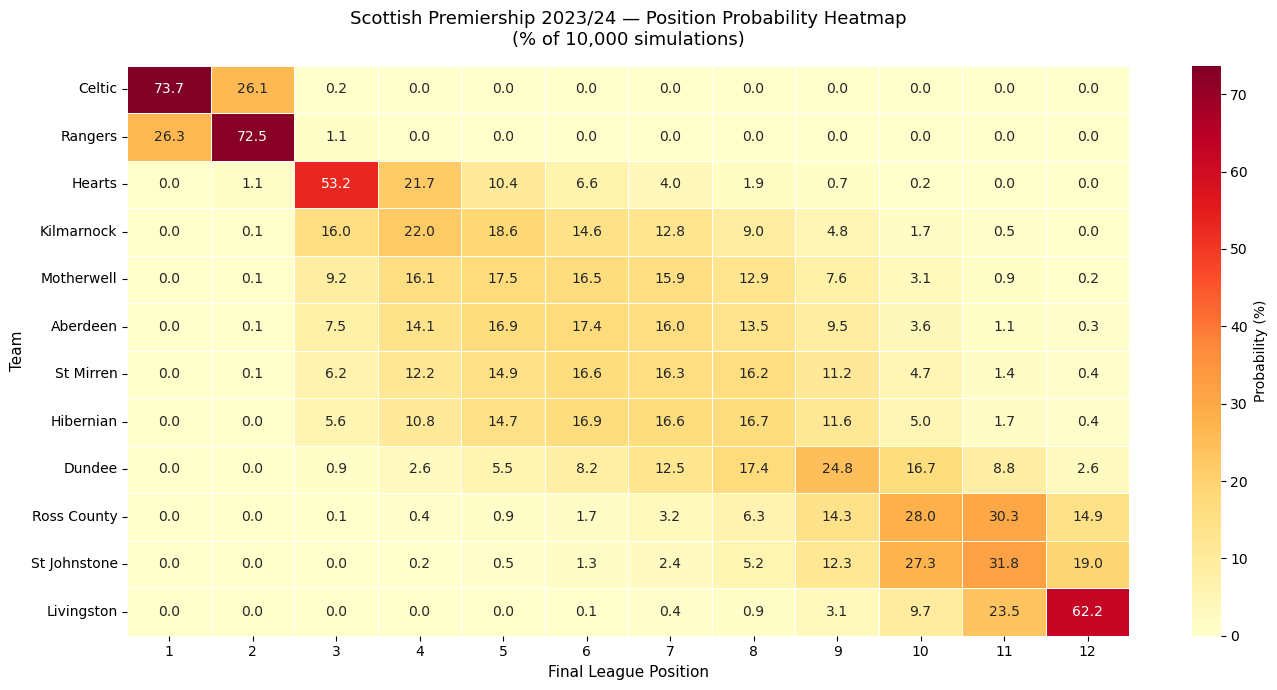

In [33]:
heatmap_data = pd.DataFrame(index=teams, columns=range(1, 13))

for team in teams:
    for pos in range(1, 13):
        heatmap_data.loc[team, pos] = round(position_counts[team][pos] / N_SIMULATIONS * 100, 1)

heatmap_data = heatmap_data.astype(float)

# Order teams by most likely finishing position
team_order = results_df.index.tolist()
heatmap_data = heatmap_data.loc[team_order]

plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.1f',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Probability (%)'},
            xticklabels=[f'{i}' for i in range(1, 13)])

plt.title('Scottish Premiership 2023/24 — Position Probability Heatmap\n(% of 10,000 simulations)', 
          fontsize=13, pad=15)
plt.xlabel('Final League Position', fontsize=11)
plt.ylabel('Team', fontsize=11)
plt.tight_layout()
plt.show()

### Key Outcome Probabilities

The bar chart below summarises the probability of each key outcome for every team, providing a clear visual comparison across the division.

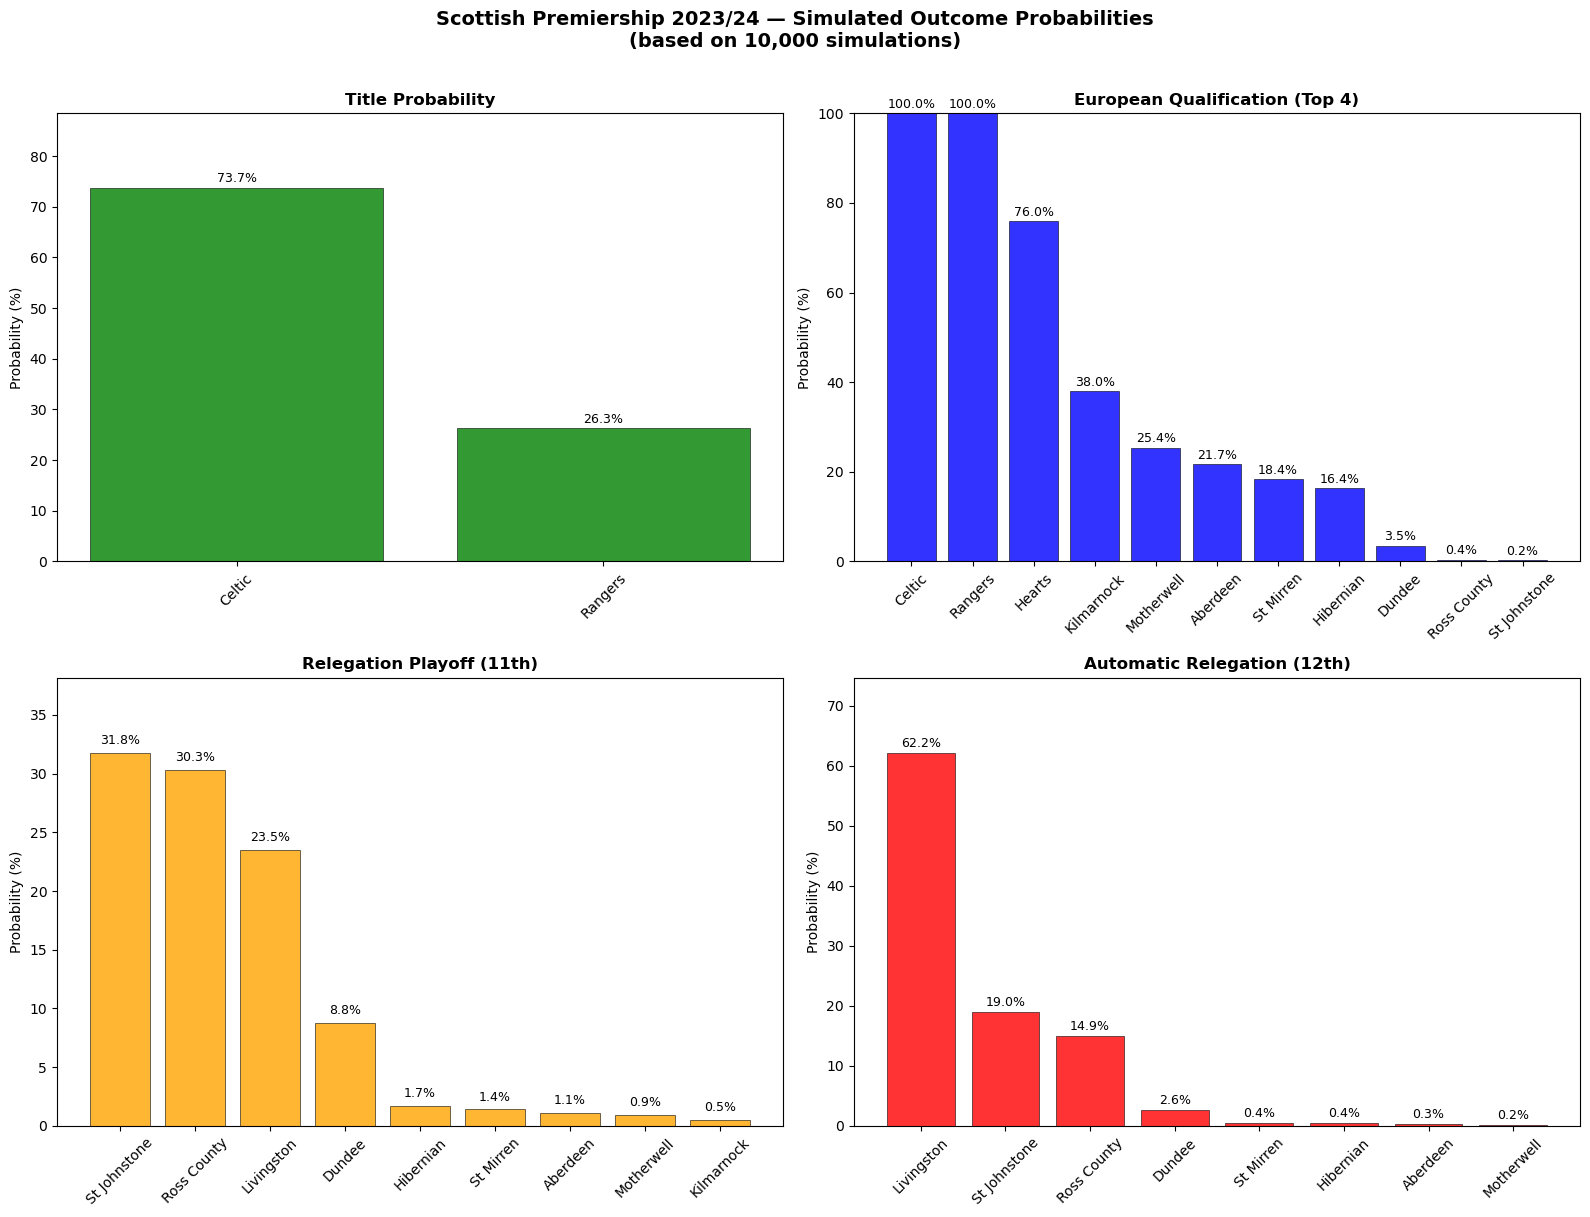

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

outcomes = ['Title %', 'Europe %', 'Playoff %', 'Relegation %']
titles = ['Title Probability', 'European Qualification (Top 4)', 
          'Relegation Playoff (11th)', 'Automatic Relegation (12th)']
colors = ['green', 'blue', 'orange', 'red']

for ax, outcome, title, color in zip(axes.flatten(), outcomes, titles, colors):
    data = results_df[outcome].sort_values(ascending=False)
    data = data[data > 0]
    
    bars = ax.bar(data.index, data.values, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Probability (%)')
    ax.set_ylim(0, min(data.values.max() * 1.2, 100))
    ax.tick_params(axis='x', rotation=45)
    
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Scottish Premiership 2023/24 — Simulated Outcome Probabilities\n(based on 10,000 simulations)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Model Validation

To assess the accuracy of our model we compare the average simulated final table across 10,000 simulations against the actual 2023/24 Scottish Premiership final standings.

If the model is well calibrated we would expect the average simulated points totals and final positions to closely mirror reality. Systematic deviations would suggest the model is overestimating or underestimating certain teams' strength.

In [37]:
actual_standings = {
    'Celtic': {'Actual Pts': 93, 'Actual Pos': 1},
    'Rangers': {'Actual Pts': 85, 'Actual Pos': 2},
    'Hearts': {'Actual Pts': 68, 'Actual Pos': 3},
    'Kilmarnock': {'Actual Pts': 56, 'Actual Pos': 4},
    'St Mirren': {'Actual Pts': 47, 'Actual Pos': 5},
    'Dundee': {'Actual Pts': 42, 'Actual Pos': 6},
    'Aberdeen': {'Actual Pts': 48, 'Actual Pos': 7},
    'Hibernian': {'Actual Pts': 46, 'Actual Pos': 8},
    'Motherwell': {'Actual Pts': 43, 'Actual Pos': 9},
    'St Johnstone': {'Actual Pts': 35, 'Actual Pos': 10},
    'Ross County': {'Actual Pts': 35, 'Actual Pos': 11},
    'Livingston': {'Actual Pts': 25, 'Actual Pos': 12},
} 

# Accumulate total points across all simulations
simulated_points = {team: [] for team in teams}

for i in range(N_SIMULATIONS):
    regular_df, top6_df, bottom6_df = simulate_full_season(teams)
    final_df = pd.concat([top6_df, bottom6_df])
    for team in teams:
        simulated_points[team].append(final_df.loc[team, 'Pts'])

# Build comparison dataframe
comparison = []
for team in teams:
    avg_pts = round(np.mean(simulated_points[team]), 1)
    actual_pts = actual_standings[team]['Actual Pts']
    actual_pos = actual_standings[team]['Actual Pos']
    comparison.append({
        'Team': team,
        'Actual Pos': actual_pos,
        'Actual Pts': actual_pts,
        'Simulated Avg Pts': avg_pts,
        'Difference': round(avg_pts - actual_pts, 1)
    })

comparison_df = pd.DataFrame(comparison).set_index('Team')
comparison_df = comparison_df.sort_values('Actual Pos')
comparison_df

,Actual Pos,Actual Pts,Simulated Avg Pts,Difference
Team,,,,
Celtic,1,93,90.1,-2.9
Rangers,2,85,84.1,-0.9
Hearts,3,68,60.0,-8.0
Kilmarnock,4,56,53.3,-2.7
St Mirren,5,47,49.8,2.8
Dundee,6,42,43.7,1.7
Aberdeen,7,48,50.6,2.6
Hibernian,8,46,49.5,3.5
Motherwell,9,43,51.5,8.5


### Validation Results

Comparing the average simulated points totals against the actual 2023/24 final standings reveals that the model performs well across most of the division.

The model has estimated 8 out of the 12 teams within 3 points of their actual points total (the difference of less than a singular win). Celtic, Rangers, Kilmarnock, St Mirren, Dundee, Aberdeen, St Johnstone and Ross County are all closely estimated, covering the title challengers, European hopefuls and relegation battlers.

The largest deviations are Hearts (-8.0 points) and Motherwell (+8.5 points). Hearts finished significanlty stronger than their goals data suggests, indicaitng they may have performed particularly well in tight matches - a characteristic the Poisson model cannot capture as it relies solely on average scoring rates. Motherwell conversely underperformed their expected output across the season. Hibernian (+3.5) and Livingston (+3.6) sit just outside the 3 point threshold, representing slight overestimation.

Overall the model demonstrates a good fit to reality, successfully capturing the broad structure of the 2023/34 season and correctly identifying the title challengers, European contenders and relegated sides.

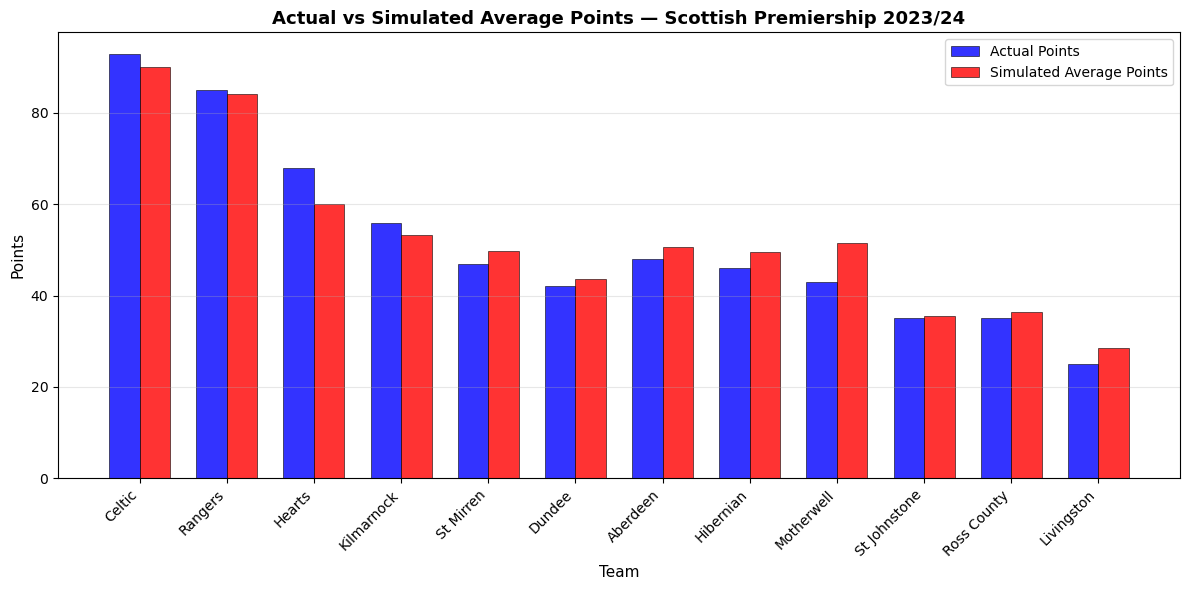

In [57]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Actual Pts'], width, 
               label='Actual Points', color='blue', alpha=0.8, edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, comparison_df['Simulated Avg Pts'], width, 
               label='Simulated Average Points', color='red', alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Team', fontsize=11)
ax.set_ylabel('Points', fontsize=11)
ax.set_title('Actual vs Simulated Average Points — Scottish Premiership 2023/24', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Limitations

While the model demonstrates a reasonable fit to the 2023/24 season, several limitations should be acknowledged.

**Independence Assumption** - the Poisson model assumes home and away goals are independent of each other. In reality a team that concedes first may alter their tactical approach, affecting subsequent scoring patterns.

**Static Team Strengths** - attack and defence strengths are estimated from the full season and treated as fixed. In reality, team strength fluctuates due to injuries, managerial changes and form. A team that has significantly improved or declines mid-season will have their strength toned down by the full season average.

**No Draw Tendency** - some teams are more prone to drawing than others. The Poisson model does not explicitly account for this, which may have contributed to deviations in the points teams who were large outliers like Hearts and Motherwell.

**Sample Size** - with only 38 home and away matches per team across the season, strength estimates are based on a relatively small sample. A single high or low scoring game can meaningfully shift a team's average.

**Fixed Match Fixture Randomisation** - in reality the SPFL schedule is fixed. Our model randomises home and away assignments in the regular season which introduces additional variance not present in real life.

## Conclusions

This project set out to to model and simulate the Scottish Premiership 2023/24 season using a Poisson Goal model and Monte Carlo Simulation. The results demonstrate that a relatively simple statistical framework can capture the broad structure of a football season with reasonable accuracy.

Key Findings:

-Celtic and Rangers are near certain to dominate with Celtic winnning the title in ~74% of simulations.

-Hearts are comfortably the strongest of the remaining clubs, reaching European qualification in ~76% of simulations.

-Livingston are the overwhelming favourites for automatic relegation at ~62%, with Ross County and St Johnstone carrying the highest playoff risk outside of Livingston - both outcomes consistent with the actual season.

-8 out of 12 teams are estimated within 3 points of their actual final points total, validating the model's fit to reality.

**Further Extensions** that would improve the model include implementing time-weighted strength estimates to account for changing form and extending to other Scottish league tiers or other seasons to further test generalisation.

This project was built entirely in Python using pandas, numpy, scipy and matplotlib, and demonsattes the application of the Poisson distribution, Monte Carlo simulation and the data science lifecycle to a real world dataset.